In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from dpsbp_operators_correct import *
from sbp_operators_periodic import * 
from RK4 import * 
from SWESBP import * 

In [2]:
import timeit

#plt.switch_backend("TkAgg")          # plots in external window
plt.switch_backend("nbagg") 


In [3]:
p1 = acoustic_sbp()
p1.mms

<bound method acoustic_sbp.mms of <SWESBP.acoustic_sbp object at 0x11c987430>>

In [4]:
# Initializations
L = 10.0         # length of the domain (km)
t = 0.0          # initial time
tend = 2    # final time
nx =  201#1281#2561 #3201#1601#3201      # grid points in x                                                                                                                       
dx = L/(nx-1)    # grid increment in x
    # velocity (km/s) (can be an array)                                                                                                             
iplot =20      # snapshot frequency
rho = 1#2.6702     # density [g/cm^3]
K =  2.2 #rho*cs**2 

g = 9.81
H = 10

Ubar=  -0.3*np.sqrt(g*H)# -0.3*np.sqrt(g*H)
#cs = np.sqrt(K/rho)# shear modulus [GPa]
#Zs = rho * cs
  # shear impedance 

order = 6# order of accuracy


#Initialize the domain
y = np.zeros((nx, 1))

# Initial particle velocity perturbation and discretize the domain
for j in range(0, nx):
    y[j, :] = j*dx                                             # discrete domain



# Time stepping parameters
cfl = 0.5                # CFL number
dt = (cfl/(np.abs(Ubar) + np.sqrt(g*H)))*dx                  # Time step
nt = int(round(tend/dt))          # number of time steps
n = 0                             # counter
print(nt)
# Boundary condition reflection coefficients 
r0 = 0                          # r=0:absorbing, r=1:free-surface, r=-1: clamped 
r1 = 0                            # r=0:absorbing, r=1:free-surface, r=-1: clamped

# penalty parameters
tau_11 = 1 #-1
tau_12 = 1.
tau_21 =  1 
tau_22 =  1

# Initialize: particle velocity (v); and shear stress (s)
v = np.zeros((nx, 1))
p = np.zeros((nx, 1))

U = np.zeros((nx, 1))
V = np.zeros((nx, 1))
U_t = np.zeros((nx, 1))
V_t = np.zeros((nx, 1))
U_x = np.zeros((nx, 1))
V_x = np.zeros((nx, 1))

                                

# Difference between analyticla and numerical solutions
EV = [0]                                 # initialize errors in V (velocity)
EU = [0]                                 # initialize errors in U (stress)
T = [0]                                  # later append every time steps to this

1030


<IPython.core.display.Javascript object>


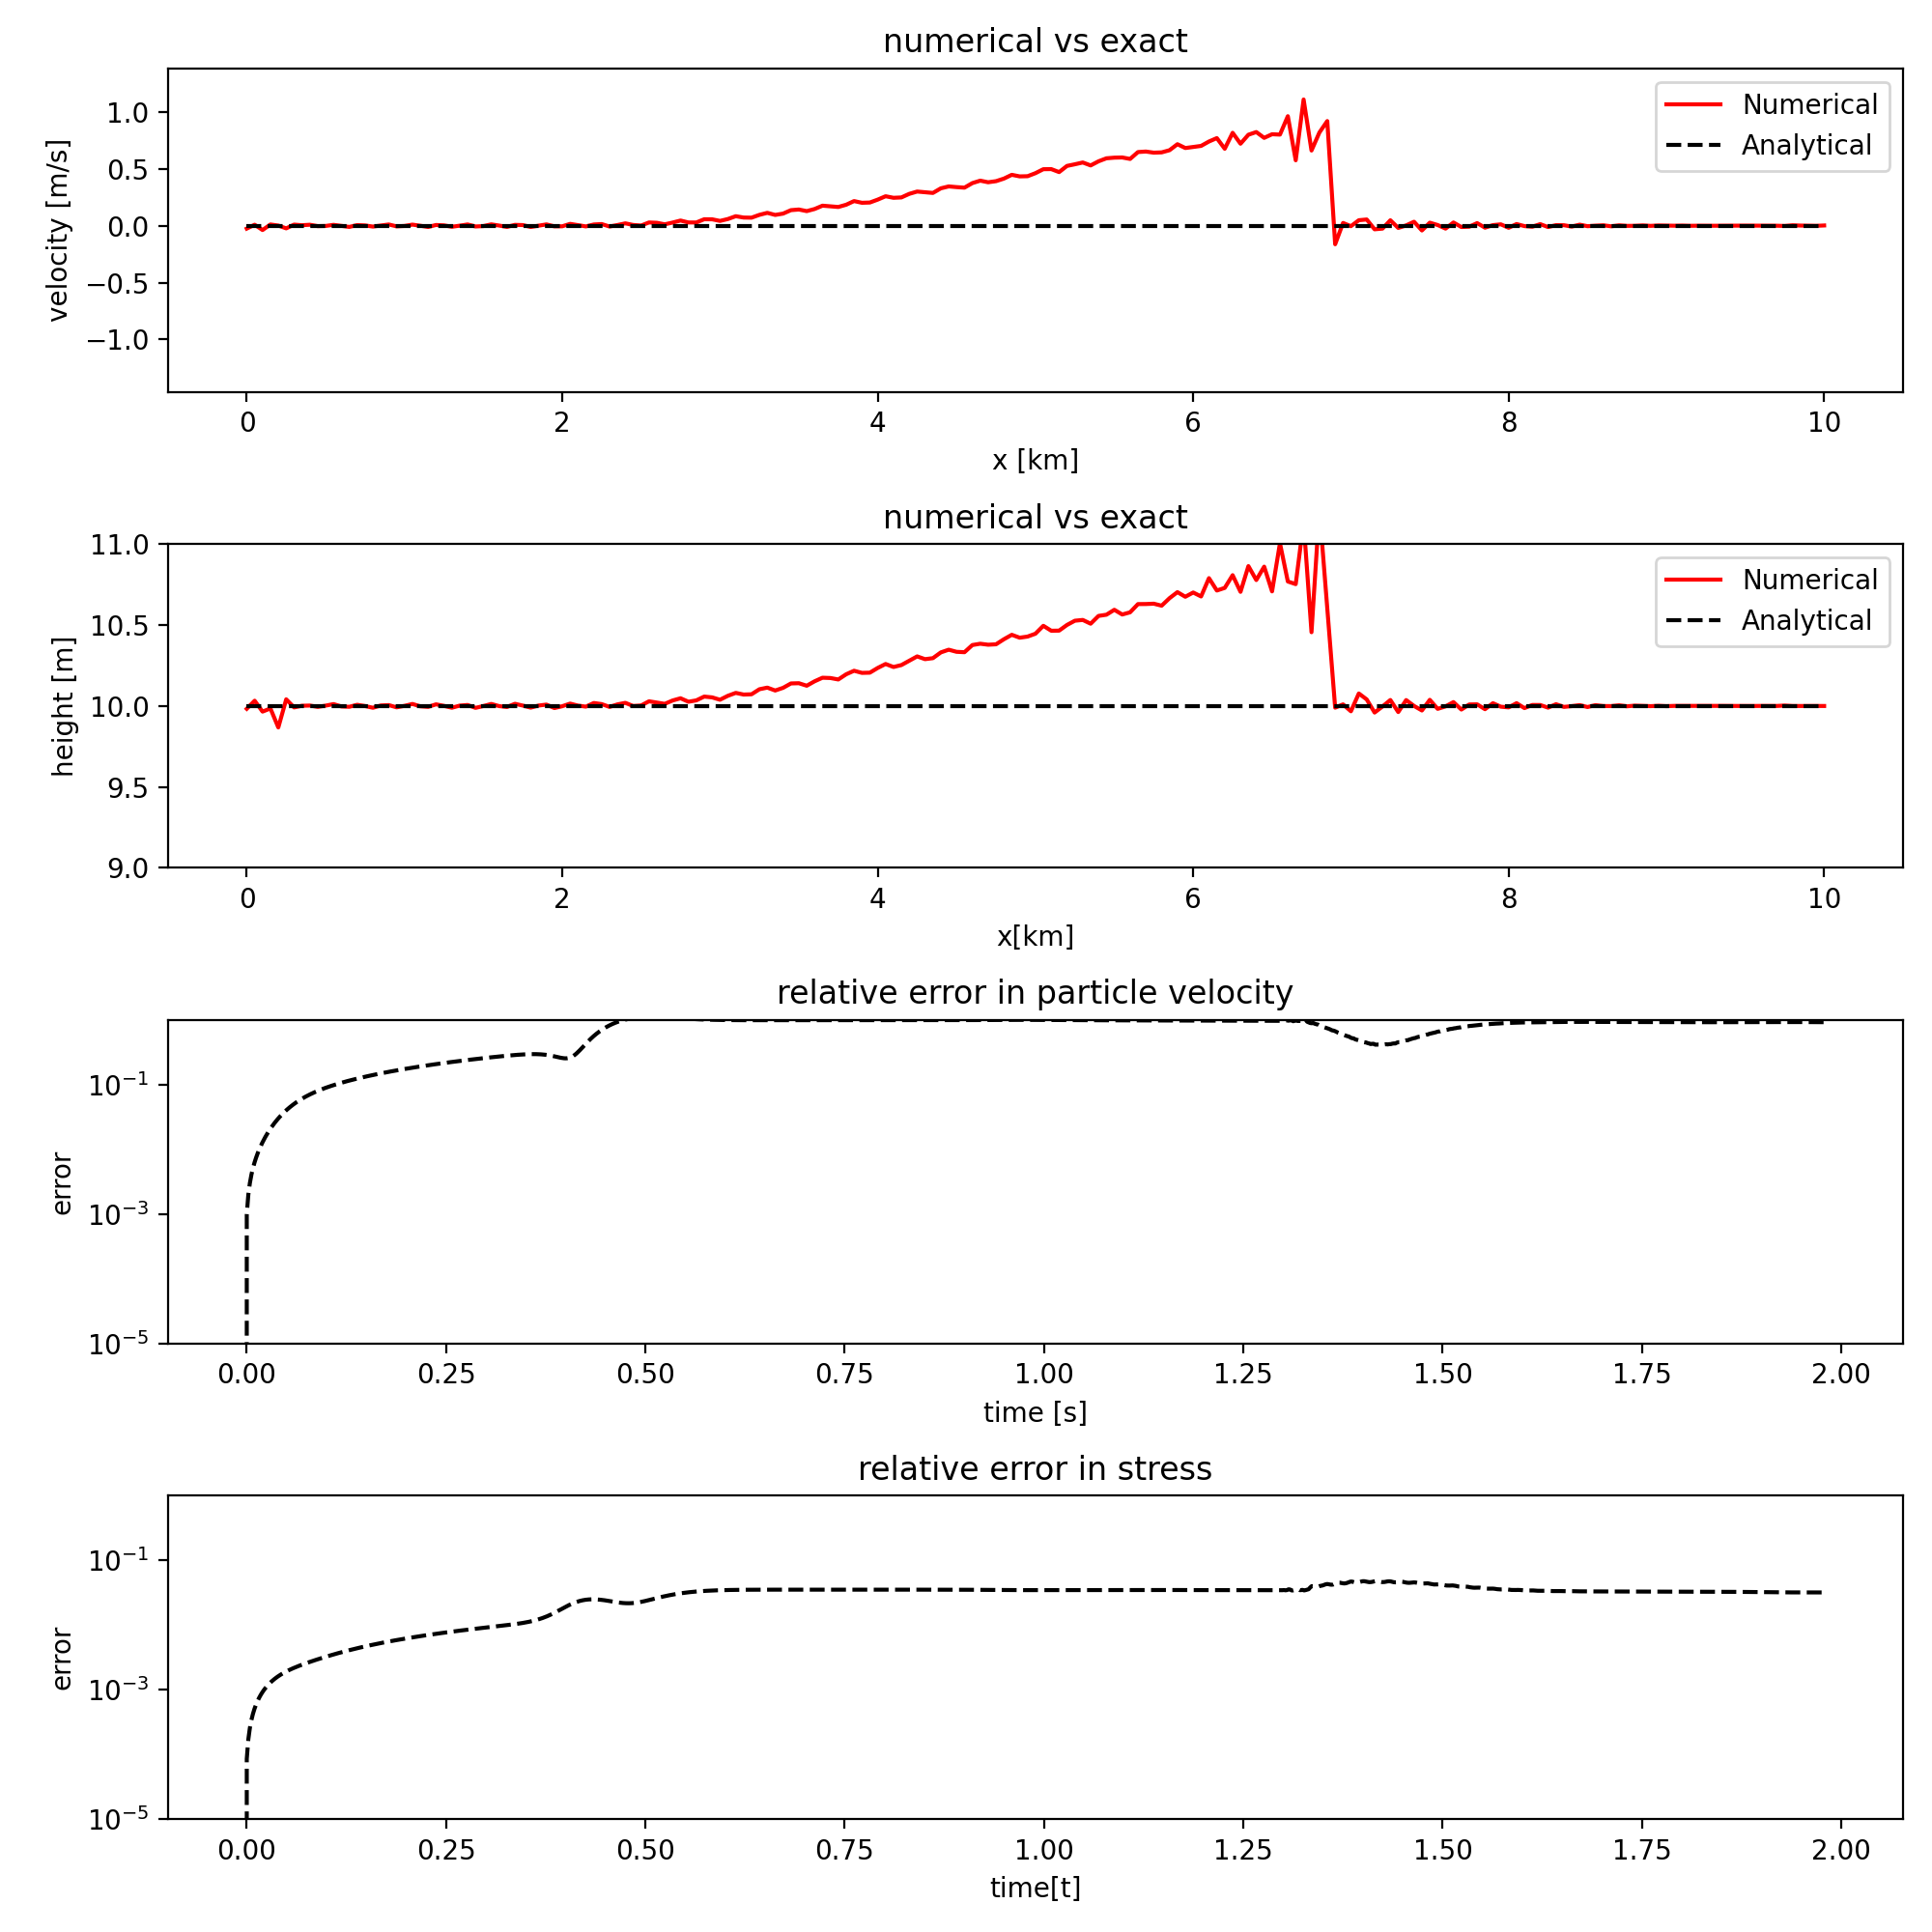

total simulation time =  19.192052665996016
spatial order | of accuracy =  6
number of grid points =  201
maximum relative error in particle velocity =  1.1049852965953293
maximum relative error in stress =  0.04771261824640922


In [5]:
# Computation and plotting

#V_alt=  np.cos(2* np.pi *t) * np.cos(5 * np.pi *y/delta + 5)#np.cos(ntv * t)*np.sin(nyv *y + fs)

#P_alt= np.sin(3*np.pi *t) * np.sin(10 * np.pi *y / delta  + 5)
# Initialize animated plot for velocity and stress
fig1 = plt.figure(figsize=(10,10))
ax1 = fig1.add_subplot(4,1,1)
line1 = ax1.plot(y, v, 'r', y, U, 'k--')
plt.title('numerical vs exact')
plt.xlabel('x [km]')
plt.ylabel('velocity [m/s]')

ax2 = fig1.add_subplot(4,1,2)
line2 = ax2.plot(y, p, 'r', y, V, 'k--')
plt.title('numerical vs exact')
plt.xlabel('x[km]')
plt.ylabel('height [m]')
ax2.set_ylim([8, 12])

# Initialize error plot (for velocity and stress)
ax3 = fig1.add_subplot(4,1,3)
line3 = ax3.plot(T, EV, 'r')
plt.title('relative error in particle velocity')
plt.xlabel('time [s]')
ax3.set_ylim([10**-5, 1])
plt.ylabel('error')

ax4 = fig1.add_subplot(4,1,4)
line4 = ax4.plot(T, EU, 'r') 
plt.ylabel('error')
plt.xlabel('time[t]')
ax4.set_ylim([10**-5, 1])
plt.title('relative error in stress')

plt.tight_layout()
plt.ion()
plt.show()


t=0   # initial time

forcing = 0.0  # forcing function, forcing = 1,  and no forcing function, forcing = 0

# type of initial data: Gaussian or Sinusoidal
type_0 = 'Gaussian'
#type_0 = 'Sinusoidal'


if type_0 in ('Sinusoidal'):
            forcing = 1.0  # we must use forcing for Sinusoidal initial condition

# L2-norm normalizer

p1.mms(v, p, U_t, V_t, U_x, V_x, y, t, type_0)
A =  (np.linalg.norm(v)) 
B =  (np.linalg.norm(p))


# Loop through time and evolve the wave-fields using ADER time-stepping scheme of N+1 order of accuracy
start = timeit.default_timer()
#type_0 = 'Sinusoidal'
# Generate initial conditions
p1.mms(v, p, U_t, V_t, U_x, V_x, y, t, type_0)

#v = 0*v

for t in np.arange(0.0, tend+dt,dt):
    n = n+1
    
    #delta = (y[-1,0]-y[0,0])
    #L = 10

    
    # compute numerical solution 
    acoustic_RK4(p1,v, p, v, p, rho, K, nx, dx, order, y, t, dt, r0, r1,  tau_11,\
                    tau_21, tau_12, tau_22, type_0, forcing, H, Ubar, g,fd_type = 'DRP')
 # Analytical solution
    p1.mms(U, V, U_t, V_t, U_x, V_x, y, t+dt, type_0 )
    
    # compute error and append to the error array
    EU.append(np.linalg.norm(U-v)/A)
    EV.append(np.linalg.norm(V-p)/B)
    
    
    T.append(t)

    # Updating plots
    if n % iplot == 0: 
        for l in line1:
            l.remove()
            del l               
        for l in line2:
            l.remove()
            del l
        for l in line3:
            l.remove()
            del l               
        for l in line4:
            l.remove()
            del l 

        # Display lines
        line1 = ax1.plot(y, v, 'r', y, U, 'k--')
        ax1.legend(iter(line1),('Numerical', 'Analytical'))
        
        line2 = ax2.plot(y, p, 'r', y, V, 'k--')
        ax2.legend(iter(line2),('Numerical', 'Analytical'))
        ax2.set_ylim([9, 11])
        #fig1.savefig('vel{}.png'.format(n))
        line3 = ax3.plot(T, EU, 'k--')
        ax3.set_yscale("log")#, nonposx='clip')
        line4 = ax4.plot(T, EV, 'k--')
        ax4.set_yscale("log")#, nonposx='clip')
        plt.gcf().canvas.draw()
        

plt.ioff()
plt.show()

# Simulation end time
stop = timeit.default_timer()
print('total simulation time = ', stop - start)                   # print the time required for simulation
print('spatial order | of accuracy = ', order)                                  # print the polynomial degree used
print('number of grid points = ', nx)                     # print the degree of freedom
print('maximum relative error in particle velocity = ', max(EU))  # max. relative error in particle velocity
print('maximum relative error in stress = ', max(EV))             # max. relative error in stress

In [6]:
!jt -t oceans16 -f roboto -fs 12 -cellw 100%

In [7]:
print('L2 absolute error in particle velocity = ', np.sqrt(dx)*np.sqrt(np.sum(np.abs(U - v)**2))) # max. relative error in particle velocity
print('L2 absolute error in stress = ', np.sqrt(dx)*np.sqrt(np.sum(np.abs(V-p)**2))) 

    #print('max absolute error = ',  np.sqrt(np.sum(np.abs(U-u)** 2)) )  # max. relative error in particle velocity
print('L2 relative error in particle velocity = ', np.sqrt(np.sum(np.abs(U - v)**2)/np.sqrt(np.sum(np.abs(v)**2)))) 
print('L2 relative error in stress = ', np.sqrt(np.sum(np.abs(V-p)**2))/np.sqrt(np.sum(np.abs(p)**2)))  

L2 absolute error in particle velocity =  1.022916521579468
L2 absolute error in stress =  1.029883105525033
L2 relative error in particle velocity =  2.1388365424030518
L2 relative error in stress =  0.03191053115481765


In [8]:
err_DP_v = [1.7372281046752163,0.5100266045490672,0.03990723543664352,0.002308613063793218,0.00012425382188266217]
err_DP_h = [1.0148956984107045,0.5571842061976883,0.09201014468649878,0.009215401812665986, 0.0009032387919208301]

In [9]:
np.log2(0.009215401812665986/0.0009032387919208301)  
err_DRP_h_new = [0.28891743791925534,0.014032945628713205,0.0011750956275785773,5.9807278688912854e-05, 2.728848910697133e-06, 1.2156013994264742e-07,5.377210632821679e-09] 
err_DRP_v_new= [0.8786779011623825,0.043766147572608244,0.003876304106010724,0.00019719834636654625,9.00908768717585e-06,4.013538512908206e-07, 1.7753240312319144e-08]

In [10]:
err_DRP_v = [2.0563788919531656,0.8205405624727541,0.0494437836862356,0.005207044784242887,0.00031376288228761995]
err_DRP_h = [ 1.0330471206199836,0.7261006904647157,0.12303685469993089,0.02090666568878922,0.0022776742602477413]

In [11]:
np.log2( 4.013538512908206e-07/ 1.7753240312319144e-08)

4.498720467687967

In [12]:
np.log2(7.812045687554418e-05/3.4729705025720026e-06)

4.491458324173736

In [13]:
err_DP_v = [0.5375802865649809,0.0354338104849249,0.0017258863346309643,7.812045687554418e-05,3.4729705025720026e-06]
err_DP_h = [0.1673226267326649,0.010850025682340579,0.0005239928884516401, 2.3680287084964075e-05,1.0521746826367362e-06]

In [14]:
from matplotlib import rcParams
import numpy as np

from numpy import meshgrid
from scipy.optimize import fsolve
from scipy import optimize
import math

rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rcParams['xtick.top'] = True
rcParams['xtick.direction'] = 'in'
rcParams['xtick.minor.visible'] = True
rcParams['ytick.right'] = True
rcParams['ytick.direction'] = 'in'
rcParams['ytick.minor.visible'] = True
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['xtick.minor.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['ytick.minor.width'] = 0.5
rcParams['font.size'] = 10


In [15]:
#ax1.plot(y, v, 'r', y, U, 'k--')


In [16]:
import matplotlib.colors as colors
import matplotlib.pylab as pl

import cmasher as cmr

In [17]:
cmap = pl.cm.jet

In [18]:
x = np.linspace(0,10,100)
y = x**2

pl.plot(x,y,color = cmap)

ValueError: <matplotlib.colors.LinearSegmentedColormap object at 0x10a3c5540> is not a valid value for color